In [346]:
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt

seed = 5
np.random.seed(seed)

result_path = Path("diagrams", "feature_weights_importances")
result_path.mkdir(exist_ok=True)

In [347]:
bias_type = "less_positive_class"
bias_strength = "0.1"
data_set_name = "breast_cancer"

In [348]:
feature_names = [
    "Clump Thickness",
    "Cell Size",
    "Cell Shape",
    "Marginal Adhesion",
    "Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",]

In [349]:
method_name = "fw-mrs-temperature"
data_path = Path("..", "thesis_results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights/weights.json")
with open(data_path, 'r') as file:
    all_feature_weights_rf = json.load(file)

data_path = Path("..", "thesis_results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_importances/feature_importances.json")
with open(data_path, 'r') as file:
    all_feature_importances_rf = json.load(file)

In [350]:
hyperparameter = "0.01"
feature_weights_dict = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
feature_importance_dict = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

feature_weights_dict_std = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
feature_importance_dict_std = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

for temperature in all_feature_weights_rf[0].keys():
    for weights_values, importance_values in zip(all_feature_weights_rf, all_feature_importances_rf):
        weights_temperature_values = weights_values[temperature][hyperparameter]
        feature_weights_dict[temperature].append(weights_temperature_values)

        weights_importance_values = importance_values[temperature][hyperparameter]
        feature_importance_dict[temperature].append(weights_importance_values)

    feature_weights_dict_std[temperature] = np.std(feature_weights_dict[temperature], axis=0)
    feature_importance_dict_std[temperature] = np.std(feature_importance_dict[temperature], axis=0)
    
    feature_weights_dict[temperature] = np.mean(feature_weights_dict[temperature], axis=0)
    feature_importance_dict[temperature] = np.mean(feature_importance_dict[temperature], axis=0)


In [351]:
weights_df = pd.DataFrame(feature_weights_dict).T
weights_df["Temperature"] = weights_df.index
weights_df.columns = feature_names +  ["Temperature"]
weights_df = pd.melt(weights_df, id_vars="Temperature")

importance_df = pd.DataFrame(feature_importance_dict).T
importance_df["Temperature"] = importance_df.index
importance_df = pd.melt(importance_df, id_vars="Temperature")

In [352]:
feature_weights_dict_std

{'0.0': array([8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
        8.32667268e-17, 8.32667268e-17, 8.32667268e-17, 8.32667268e-17,
        8.32667268e-17]),
 '0.1': array([0.04199801, 0.04321285, 0.04097677, 0.04280193, 0.04426647,
        0.0376522 , 0.04143769, 0.04241141, 0.03477461]),
 '0.05': array([0.06321548, 0.0658941 , 0.05289825, 0.07370375, 0.08077052,
        0.0537136 , 0.07104682, 0.06826394, 0.07944376]),
 '0.01': array([0.08109679, 0.14301869, 0.01709991, 0.18233127, 0.2253107 ,
        0.0906831 , 0.17721925, 0.09735314, 0.33566385]),
 '0.005': array([0.06490583, 0.17615496, 0.00192429, 0.24132547, 0.26204866,
        0.11331894, 0.22351944, 0.08431895, 0.4142368 ])}

In [353]:
feature_weights_std_list = []
for i in range(9):
    feature_weights_std_list.extend(np.array(list(feature_weights_dict_std.values()))[:, i])

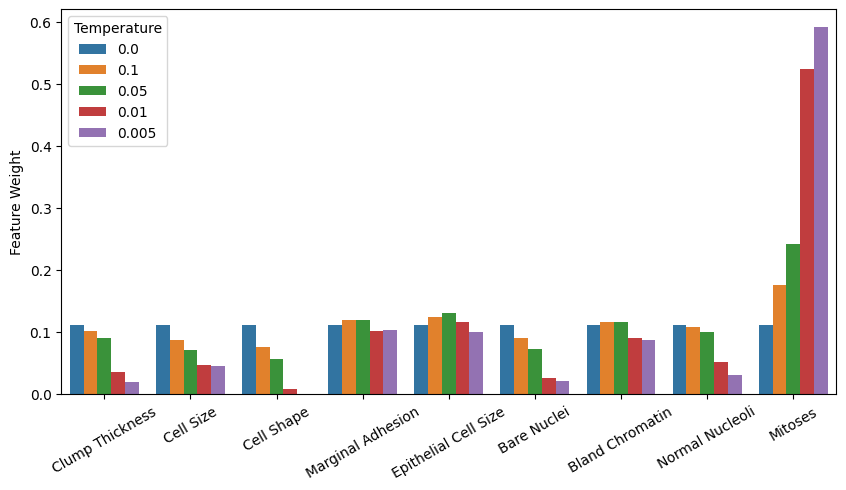

In [354]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=weights_df, x="variable",  y="value", hue="Temperature")
ax.set(xlabel='', ylabel='Feature Weight')
plt.xticks(rotation=30)
            
plt.savefig("diagrams/feature_weights.pdf", bbox_inches='tight')

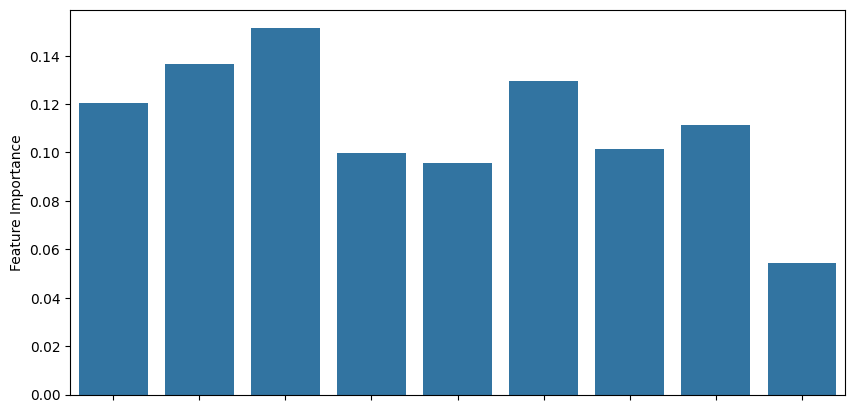

In [367]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=importance_df, x="variable", y="value", err_kws={'linewidth': 0})
ax.set(xlabel='', ylabel='Feature Importance', xticklabels=[])
plt.savefig("diagrams/feature_importance.pdf", bbox_inches='tight')

In [356]:
iteration = np.random.randint(low=0, high=len(all_feature_weights_rf))
individual_feature_weights_rf = all_feature_weights_rf[iteration]["0.1"]["0.0"]
individual_feature_importances_rf = all_feature_importances_rf[iteration]["0.1"]["0.0"]

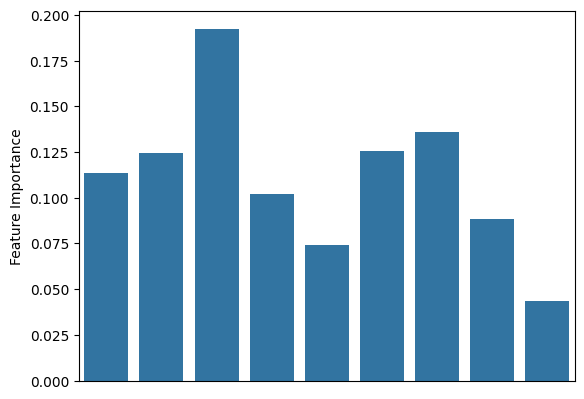

In [357]:
sns.barplot(individual_feature_weights_rf).set(ylabel="Feature Weight")
_ = plt.xticks(list(range(0, len(individual_feature_weights_rf), 2)))
plt.savefig(result_path / "individual_feature_weights_rf.pdf")
plt.xticks(visible=False)
plt.xticks(ticks=[], labels=[])
plt.clf()

sns.barplot(individual_feature_importances_rf).set(ylabel="Feature Importance")
_ = plt.xticks(list(range(0, len(individual_feature_importances_rf), 2)))
plt.xticks(visible=False)
plt.xticks(ticks=[], labels=[])
plt.savefig(result_path / "individual_feature_importances_rf.pdf")

In [358]:
method_name = "fw-mrs-temperature-svm"
data_path = Path("..", "thesis_results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights", "weights.json")
with open(data_path, 'r') as file:
    all_feature_weights = json.load(file)

data_path = Path("..", "thesis_results", "temperature_comparison", data_set_name, bias_type, bias_strength,
                  method_name, "feature_importances", "feature_importances.json")
with open(data_path, 'r') as file:
    all_feature_importances = json.load(file)

individual_feature_weights = all_feature_weights[iteration]["0.1"]["10.0"]
individual_feature_importances = all_feature_importances[iteration]["0.1"]["10.0"]

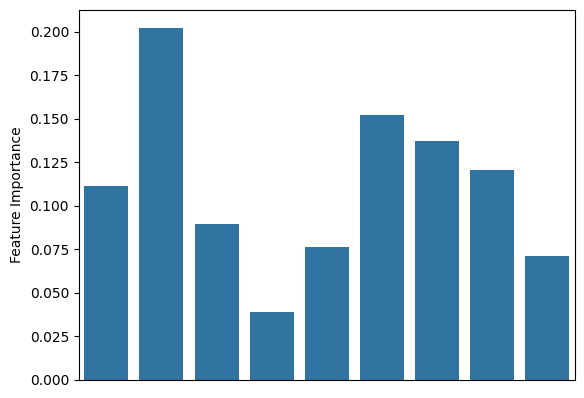

In [359]:
sns.barplot(individual_feature_weights).set(ylabel="Feature Weight")
_ = plt.xticks(list(range(0, len(individual_feature_weights), 2)))
plt.savefig(result_path / "individual_feature_weights_svm.pdf")
plt.xticks(visible=False)
plt.xticks(ticks=[], labels=[])
plt.clf()

sns.barplot(individual_feature_importances).set(ylabel="Feature Importance")
_ = plt.xticks(list(range(0, len(individual_feature_weights), 2)))
plt.xticks(visible=False)
plt.xticks(ticks=[], labels=[])
plt.savefig(result_path / "individual_feature_importances_svm.pdf")